In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import scipy.stats as stats 

In [9]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [13]:
X = df.drop("price", axis=1)
y = df["price"]
X = pd.get_dummies(X, drop_first=True)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)

In [17]:
residuals = y_test - y_pred

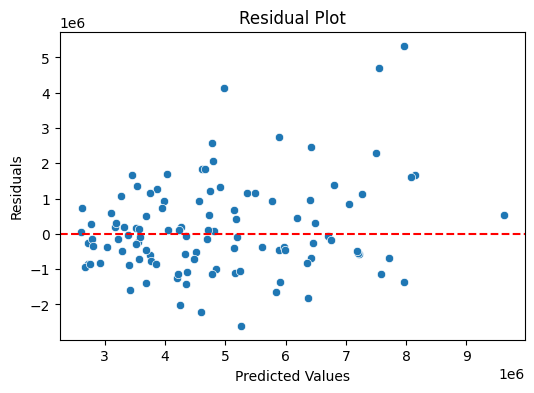

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

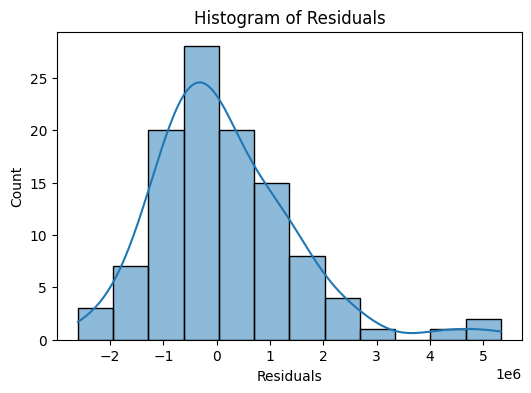

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.show()

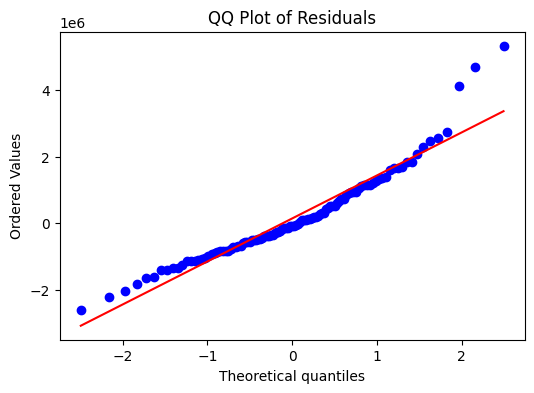

In [20]:
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()

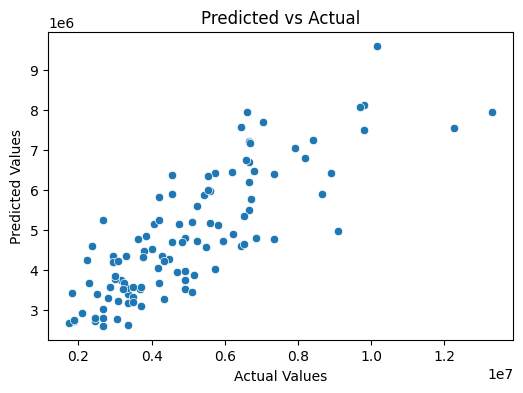

In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")
plt.show()

In [22]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6529242642153184


In [ ]:
answers to the questions
Q1 Are residuals normally distributed?
Ans->Yes, the residuals are approximately normally distributed. The histogram shows a roughly bell-shaped distribution and
the QQ plot shows most points lying close to the reference line, indicating that the normality assumption is reasonably satisfied.
Q2 Is there heteroscedasticity?
Ans->The residual plot shows points randomly scattered around the zero line, indicating that strong heteroscedasticity is not present.
However, a slight increase in spread at higher predicted values suggests mild heteroscedasticity.
Q3 How would you fix violations?
Ans->Violations can be addressed by applying transformations such as logarithmic transformation, removing extreme outliers, performing feature engineering, or
using regularized regression methods likeRidge or Lasso to improve model stability.